In [7]:
import numpy as np
import matplotlib.pyplot as plt

h = 6.62607015e-34  # Planck's constant in J*s
k_B = 1.380649e-23   # Boltzmann's constant in

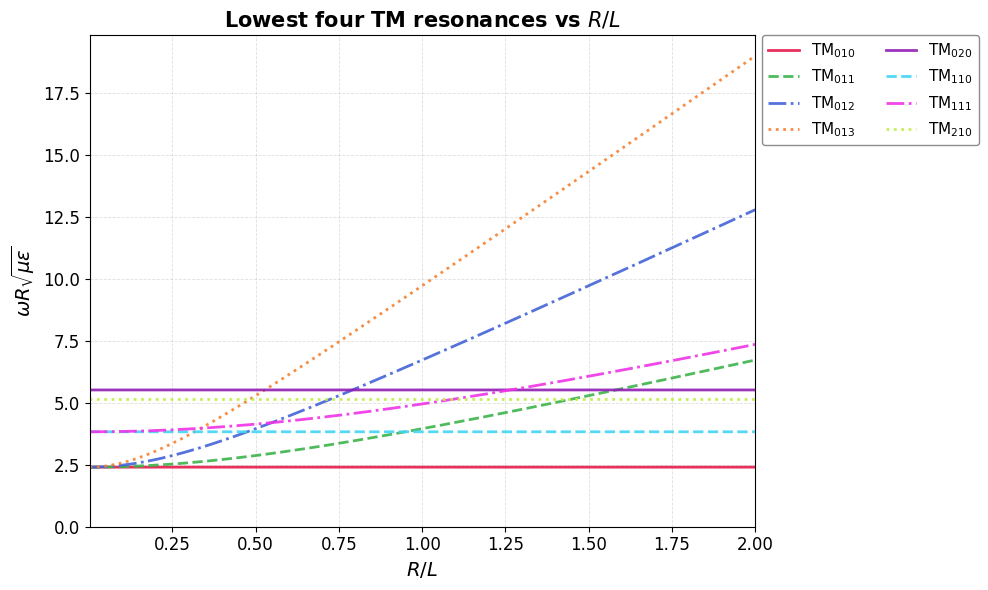

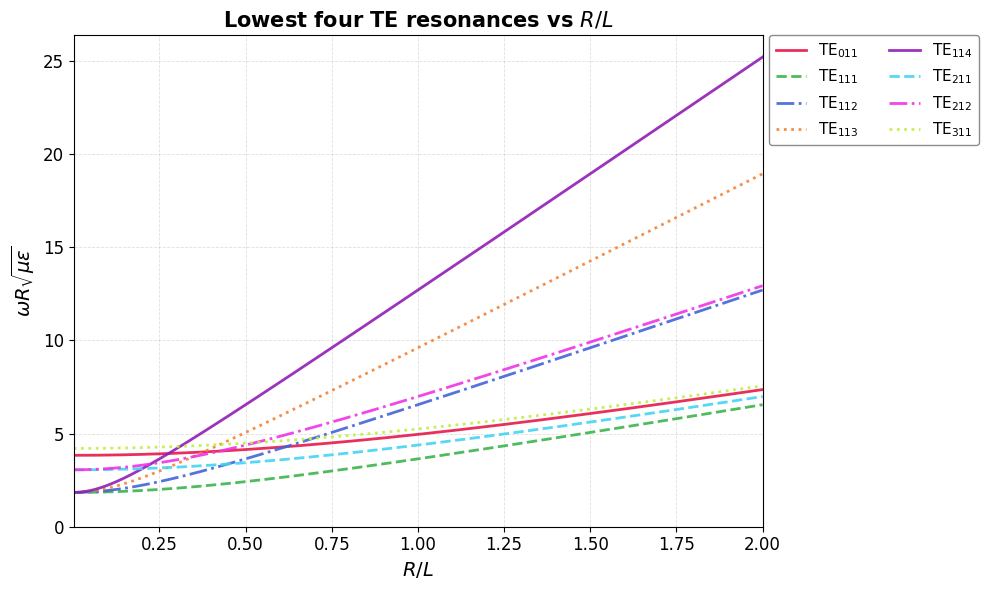

In [8]:
from scipy.special import jn_zeros, jnp_zeros

# ------------------------------------------------------------
# Jackson 8.6(a): cylindrical cavity
#
# Normalized frequency:
#   Omega = omega * R * sqrt(mu*epsilon)
#
# TM modes:
#   Omega_TM(n,m,l) = sqrt( P_nm^2 + (l*pi*R/L)^2 )
#   where P_nm is the mth zero of J_n
#   and l = 0,1,2,...
#
# TE modes:
#   Omega_TE(n,m,l) = sqrt( P'_nm^2 + (l*pi*R/L)^2 )
#   where P'_nm is the mth zero of J_n'
#   and l = 1,2,3,...
# ------------------------------------------------------------

# Range of R/L
rho = np.linspace(0.001, 2.0, 1200)   # rho = R/L

# How many candidate modes to generate.
n_max = 5          # max azimuthal index n
m_roots_per_n = 4  # how many radial zeros P_nm to compute per n
l_max_tm = 5       # max axial index l for TM (l >= 0)
l_max_te = 5       # max axial index l for TE (l >= 1)


def generate_tm_modes(rho, n_max=5, m_roots_per_n=4, l_max=5):
    """
    Generate TM mode families for a cylindrical cavity.

    TM(n,m,l): Omega = sqrt( P_nm^2 + (l*pi*rho)^2 )
      n = azimuthal index (Bessel order)
      m = radial index    (mth zero of J_n, i.e. P_nm)
      l = axial index     (l = 0,1,2,...  — l=0 is allowed for TM)
    """
    modes = []
    for n in range(n_max + 1):
        P_nm = jn_zeros(n, m_roots_per_n)   # mth zeros of J_n
        for m, pnm in enumerate(P_nm, start=1):
            for l in range(0, l_max + 1):          # l=0 allowed for TM
                omega_norm = np.sqrt(pnm**2 + (l * np.pi * rho)**2)
                label = f"TM$_{{{n}{m}{l}}}$"
                modes.append((label, omega_norm))
    return modes


def generate_te_modes(rho, n_max=5, m_roots_per_n=4, l_max=5):
    """
    Generate TE mode families for a cylindrical cavity.

    TE(n,m,l): Omega = sqrt( P'_nm^2 + (l*pi*rho)^2 )
      n = azimuthal index (Bessel order)
      m = radial index    (mth zero of J_n', i.e. P'_nm)
      l = axial index     (l = 1,2,3,...  — l=0 does not exist for TE)
    """
    modes = []
    for n in range(n_max + 1):
        P_prime_nm = jnp_zeros(n, m_roots_per_n)  # mth zeros of J_n'
        for m, p_prime_nm in enumerate(P_prime_nm, start=1):
            for l in range(1, l_max + 1):          # l=0 does not exist for TE
                omega_norm = np.sqrt(p_prime_nm**2 + (l * np.pi * rho)**2)
                label = f"TE$_{{{n}{m}{l}}}$"
                modes.append((label, omega_norm))
    return modes


# Distinct colors and line styles for up to ~12 mode families
COLORS = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231",
    "#911eb4", "#42d4f4", "#f032e6", "#bfef45",
    "#fabed4", "#469990", "#dcbeff", "#9A6324",
]
LINE_STYLES = ["-", "--", "-.", ":"]


def plot_lowest_four(rho, modes, title):
    """
    Plot every mode family that appears among the lowest four somewhere
    in the rho range, with improved color coordination and readability.
    """
    values = np.array([vals for _, vals in modes])   # shape = (Nmodes, Nrho)

    # Indices of the lowest 4 modes at each rho sample
    lowest4_idx = np.argsort(values, axis=0)[:4, :]

    # Find all mode families that ever appear among the lowest 4
    mode_indices_to_plot = sorted(set(lowest4_idx.flatten()))

    fig, ax = plt.subplots(figsize=(10, 6))

    for i, idx in enumerate(mode_indices_to_plot):
        label, vals = modes[idx]
        color = COLORS[i % len(COLORS)]
        ls = LINE_STYLES[i % len(LINE_STYLES)]
        ax.plot(rho, vals, label=label, color=color, linestyle=ls,
                linewidth=2.0, alpha=0.9)

    ax.set_xlabel(r"$R/L$", fontsize=14)
    ax.set_ylabel(r"$\omega R\sqrt{\mu\epsilon}$", fontsize=14)
    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_xlim(rho.min(), rho.max())
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=12)

    # Subtle grid on major ticks only
    ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.4)

    # Legend outside the plot area to avoid overlap with curves
    ax.legend(
        ncol=2, fontsize=11,
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        borderaxespad=0,
        framealpha=0.9,
        edgecolor="gray",
    )

    fig.tight_layout()


# Generate candidate mode families
tm_modes = generate_tm_modes(rho, n_max=n_max, m_roots_per_n=m_roots_per_n, l_max=l_max_tm)
te_modes = generate_te_modes(rho, n_max=n_max, m_roots_per_n=m_roots_per_n, l_max=l_max_te)

# Plot lowest four TM and TE families
plot_lowest_four(rho, tm_modes, r"Lowest four TM resonances vs $R/L$")
plot_lowest_four(rho, te_modes, r"Lowest four TE resonances vs $R/L$")

plt.show()